### E-Commerce US Dataset -- Data Cleaning

\Importing Necessary Libraries

In [30]:
import numpy as np
import pandas as pd
import os

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [29]:
sns.set_style("whitegrid")          
plt.rcParams["figure.figsize"] = (10, 5)  
plt.rcParams["axes.titlesize"] = 13

\Loading the integrated dataset

In [3]:
integrated_path = r"C:\NG\E-Commerce US dataset\E-Commerce-US-dataset\data\raw_integrated"

master = pd.read_csv(os.path.join(integrated_path,"master_orders.csv"))
items_enriched = pd.read_csv(os.path.join(integrated_path,"items_enriched.csv"))

\Date Conversion

In [9]:
#date conversion fn
def convert_date(df, date_cols):
    for col in date_cols:
        if col in df.columns:
            df[col]=pd.to_datetime(df[col],errors= "coerce")
    return df

In [11]:
date_cols = ["order_purchase_timestamp","order_approved_at",
             "order_delivered_carrier_date","order_delivered_customer_date",
             "order_estimated_delivery_date"]
convert_date(master,date_cols)
master[date_cols].dtypes

order_purchase_timestamp         datetime64[us]
order_approved_at                datetime64[us]
order_delivered_carrier_date     datetime64[us]
order_delivered_customer_date    datetime64[us]
order_estimated_delivery_date    datetime64[us]
dtype: object

\Missing value treatment

In [12]:
master["has_review"] =master["avg_review_score"].notna().astype(int)
master["n_reviews"] =master["n_reviews"].fillna(0).astype(int)
master["is_delivered"] =master["order_delivered_customer_date"].notna().astype(int)

In [13]:
master["customer_age"] = master["customer_age"].astype(int)
master["n_items"] = master["n_items"].fillna(0).astype(int)
for col in ["total_price","total_freight","total_payment"]:
    if col in master.columns:
        master[col] = master[col].round(2)

\items_enriched cleaning

In [18]:
items_enriched = convert_date(items_enriched, ["shipping_limit_date"])

In [20]:
if "price_prod" in items_enriched.columns:
    items = items_enriched.drop(columns=["price_prod"])

In [21]:
items_enriched["seller_contact_age"] = items_enriched["seller_contact_age"].astype(int)
for col in ["price","freight_value","cost","discount_rate"]:
    if col in items_enriched.columns:
        items_enriched[col] = items_enriched[col].round(2)

In [22]:
items_enriched["profit"] = (items_enriched["price"] - items_enriched["cost"]).round(2)
items_enriched["profit_margin_pct"] = ((items_enriched["profit"] / items_enriched["price"]) * 100).round(2)

\Saving the cleaned dataset

In [26]:
master.to_csv(os.path.join(integrated_path, "master_clean.csv"), index=False)
items.to_csv(os.path.join(integrated_path, "items_clean.csv"), index=False)

### EDA

\Customer Analysis

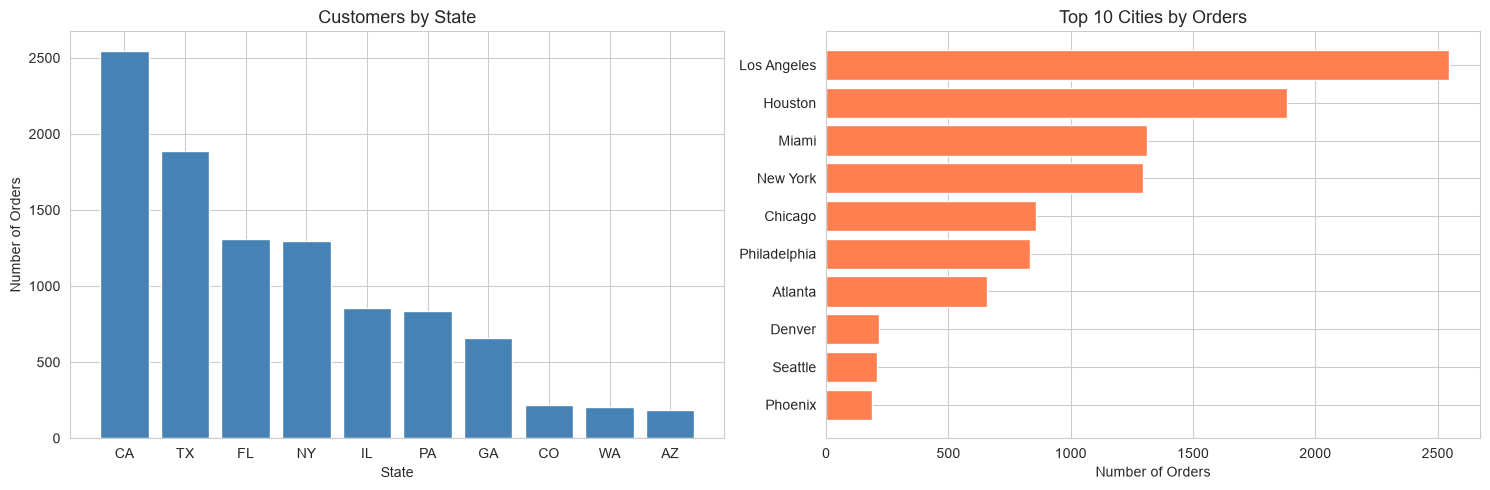

Top 3 states: {'CA': 2546, 'TX': 1885, 'FL': 1312}


In [31]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

state_counts = master["customer_state"].value_counts()
axes[0].bar(state_counts.index, state_counts.values, color="steelblue")
axes[0].set_title("Customers by State")
axes[0].set_xlabel("State"); axes[0].set_ylabel("Number of Orders")

city_counts = master["customer_city"].value_counts().head(10)
axes[1].barh(city_counts.index[::-1], city_counts.values[::-1], color="coral")
axes[1].set_title("Top 10 Cities by Orders")
axes[1].set_xlabel("Number of Orders")

plt.tight_layout()
plt.savefig("customer_distribution.png", dpi=100, bbox_inches="tight")
plt.show()

print("Top 3 states:", state_counts.head(3).to_dict())

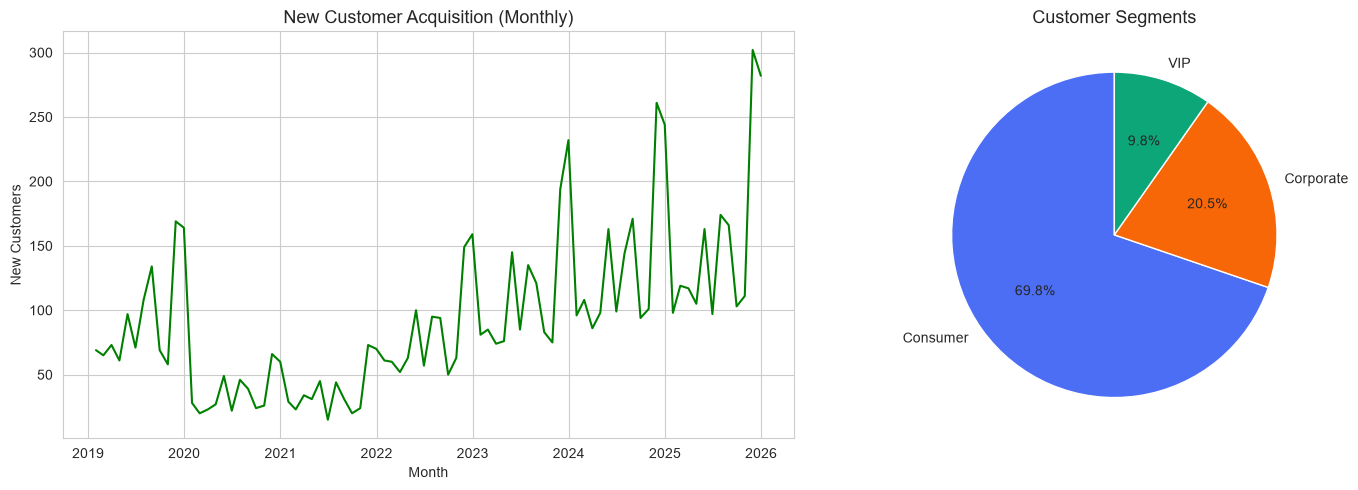

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

master_sorted = master.sort_values("order_purchase_timestamp")
first_orders = master_sorted.drop_duplicates("customer_unique_id", keep="first")
monthly_new = first_orders.set_index("order_purchase_timestamp").resample("ME").size()

axes[0].plot(monthly_new.index, monthly_new.values, color="green", linewidth=1.5)
axes[0].set_title("New Customer Acquisition (Monthly)")
axes[0].set_xlabel("Month"); axes[0].set_ylabel("New Customers")

seg_counts = master["customer_segment"].value_counts()
axes[1].pie(seg_counts.values, labels=seg_counts.index, autopct="%1.1f%%",
            colors=["#4C6EF5","#F76707","#0CA678"], startangle=90)
axes[1].set_title("Customer Segments")

plt.tight_layout()
plt.savefig("customer_acquisition.png", dpi=100, bbox_inches="tight")
plt.show()

\order Analysis

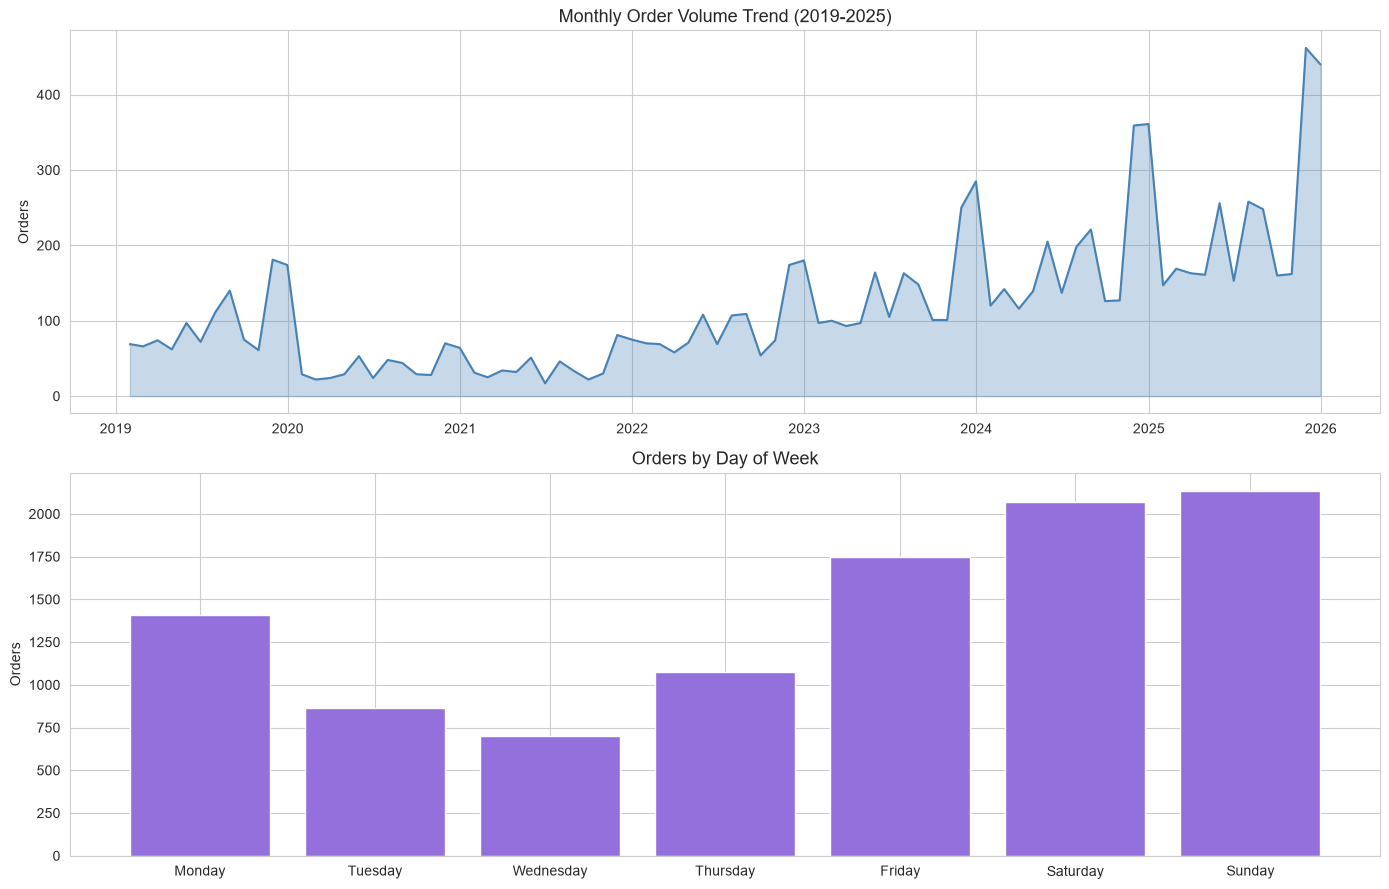

In [33]:

fig, axes = plt.subplots(2, 1, figsize=(14, 9))

monthly_orders = master.set_index("order_purchase_timestamp").resample("ME").size()
axes[0].plot(monthly_orders.index, monthly_orders.values, color="steelblue", linewidth=1.5)
axes[0].fill_between(monthly_orders.index, monthly_orders.values, alpha=0.3, color="steelblue")
axes[0].set_title("Monthly Order Volume Trend (2019-2025)")
axes[0].set_ylabel("Orders")

master["day_of_week"] = master["order_purchase_timestamp"].dt.day_name()
dow_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
dow_counts = master["day_of_week"].value_counts().reindex(dow_order)
axes[1].bar(dow_counts.index, dow_counts.values, color="mediumpurple")
axes[1].set_title("Orders by Day of Week")
axes[1].set_ylabel("Orders")

plt.tight_layout()
plt.savefig("order_volume_trends.png", dpi=100, bbox_inches="tight")
plt.show()

In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

status_counts = master["order_status"].value_counts()
axes[0].pie(status_counts.values, labels=status_counts.index, autopct="%1.1f%%",
            colors=["#0CA678","#E03131"], startangle=90)
axes[0].set_title("Order Status Distribution")


delivered = master[master["is_delivered"]==1].copy()
delivered["delivery_days"] = (delivered["order_delivered_customer_date"] -
                               delivered["order_purchase_timestamp"]).dt.days
delivered["est_days"] = (delivered["order_estimated_delivery_date"] -
                          delivered["order_purchase_timestamp"]).dt.days
delivered["on_time"] = (delivered["delivery_days"] <= delivered["est_days"])
